# Notebook 02 — Estimation Analysis

## Research Questions
1. **Q1 (Estimasi):** Berapa probabilitas sebuah PR di-merge, dan seberapa tidak pasti estimasi tersebut?
2. **Q2 (Inferensi):** Apakah rata-rata jumlah komentar berbeda secara signifikan antara PR yang merged vs unmerged?
3. **Q3 (Simulasi):** Berapa probabilitas sebuah issue butuh lebih dari 30 hari untuk ditutup?

## Member
- **Nama:** Raynar Usman Annafis
- **Role:** Estimation Analyst (Member B)
- **Repository:** pandas-dev/pandas

## AI Usage Disclosure

**Member:** Raynar Usman Annafis — Estimation Analyst (Member B)  
**Tools used:** Deepseek

| Task | Tool | Prompt summary | Output modified? |
|---|---|---|---|
| Mereferensikan data berdasarkan cleaning data yang telah diolah oleh Data Engineer | Deepseek | "saya memiliki tugas kuliah sebagai estimation analyst, sebelum melakukan estimasi tolong bantu saya import library yang dibutuhkan dan bantu saya referensikan data berdasarkan issues_clean.csv dan pr_clean.csv" | Ya — disesuaikan dengan cleaning data |
| Proses coding estimation analyst | Deepseek | "berdasarkan data yang direferensikan, lakukan estimation analyst dengan pendekatan menggunakan pendekatan MLE Derivation, Beta Posterior, Likelihood Visualisation (rumus disesuaikan dengan pada repository detail tugas Formula Accuracy Formula dan Source Modules)" | Ya — hasil output disesuaikan dengan research question 1 |
| Debugging error library dan error output | Deepseek | "saya memiliki masalah pada referensi data yang gagal diproses dan command plt yang tidak berjalan" | Ya — perbaikan penulisan path agar dapat dibaca |

**Written entirely without AI:** Interpretasi hasil estimasi (Q1), MLE derivation steps

## 1. Import Library

In [5]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta as beta_dist

print("✓ Semua library berhasil diimport")

# 1. Tentukan path folder utama (root project) berdasarkan lokasi saat ini
# Karena kamu berada di folder 'notebooks', kita mundur 1 langkah (..) untuk ke 'final_project'
root_path = os.path.abspath('..') 

# 2. Cari kemungkinan lokasi estimator.py secara dinamis
# Opsi 1: File berada langsung di C:\StatProb\final_project\estimator.py
path_opsi_1 = os.path.join(root_path, 'estimator.py')

# Opsi 2: File berada di dalam folder src (C:\StatProb\final_project\src\estimator.py)
path_opsi_2 = os.path.join(root_path, 'src', 'estimator.py')

# 3. Pengecekan dan registrasi ke Python System Path
if os.path.exists(path_opsi_1):
    sys.path.append(root_path)
    print("✓ estimator.py ditemukan langsung di folder utama project!")
    print("Path:", path_opsi_1)
    
elif os.path.exists(path_opsi_2):
    sys.path.append(os.path.join(root_path, 'src'))
    print("✓ estimator.py ditemukan di dalam folder 'src'!")
    print("Path:", path_opsi_2)
    
else:
    print("✗ estimator.py TIDAK ditemukan.")
    print(f"Dicari di {path_opsi_1} maupun {path_opsi_2}")
    print("\nTIPS: Pastikan kamu sudah membuat file bernama 'estimator.py' dan menyimpannya di folder 'final_project' atau di dalam 'final_project/src'.")




✓ Semua library berhasil diimport
✓ estimator.py ditemukan di dalam folder 'src'!
Path: c:\StatProb\final_project\src\estimator.py


## 2. Import Fungsi dari `estimator.py`

In [11]:
import importlib
import estimator

# Paksa Jupyter membuang cache dan membaca ulang isi file estimator.py
importlib.reload(estimator)

# Import ulang fungsi-fungsinya setelah di-reload
from estimator import (
    mle_bernoulli,
    log_likelihood_bernoulli,
    mle_poisson,
    log_likelihood_poisson,
    beta_posterior
)

print("✓ Modul estimator berhasil di-reload paksa secara total!")

✓ Modul estimator berhasil di-reload paksa secara total!


## 3. Load Data

Data yang digunakan adalah `pr_clean.csv` yang telah dibersihkan oleh Data Engineer (Member A).  
Kolom yang relevan untuk Q1 adalah **`status`** (merged / unmerged).

In [17]:

# Baca data pr_clean.csv dari folder data/clean/
path_pr = os.path.abspath('../data/clean/pr_clean.csv')
df_pr = pd.read_csv(path_pr)

print(f"Total data PR  : {len(df_pr)}")
print(f"Kolom tersedia : {df_pr.columns.tolist()}")
print(f"Nilai unik 'status': {df_pr['status'].unique()}")

# Sample tabel — 5 baris pertama (referensi dari EDA Member A)
df_pr.head()

Total data PR  : 789
Kolom tersedia : ['number', 'title', 'status', 'created_at', 'closed_at', 'comments', 'user']
Nilai unik 'status': <ArrowStringArray>
['merged', 'unmerged']
Length: 2, dtype: str


,number,title,status,created_at,closed_at,comments,user
0,65697,"Revert ""BUG: reject unhashable elements in Ind...",merged,2026-05-20 16:38:19+00:00,2026-05-20 21:22:12+00:00,1,jorisvandenbossche
1,65693,[backport 3.0.x] TST: Adjust xfails for fastpa...,merged,2026-05-20 14:03:23+00:00,2026-05-20 16:33:10+00:00,0,jorisvandenbossche
2,65686,BUG: Fix Index.where raising AssertionError wh...,merged,2026-05-19 18:54:58+00:00,2026-05-21 14:34:32+00:00,7,anzinmhd
3,65681,ASV: garbage collect as part of setup,merged,2026-05-18 21:24:09+00:00,2026-05-23 17:26:56+00:00,1,rhshadrach
4,65680,Bump github/codeql-action from 4.35.4 to 4.35.5,merged,2026-05-18 13:54:43+00:00,2026-05-18 15:27:45+00:00,0,dependabot[bot]


## 4. Research Question 1 — Estimasi Probabilitas PR di-Merge

> **Q1:** Berapa probabilitas sebuah PR di-merge, dan seberapa tidak pasti estimasi tersebut?

### 4.1 Statistik Deskriptif

In [18]:
# Hitung jumlah PR merged (k) dan total PR (n)
k = (df_pr['status'] == 'merged').sum()
n = len(df_pr)
m = n - k  # jumlah PR unmerged

print("=" * 50)
print("STATISTIK DESKRIPTIF PR")
print("=" * 50)
print(f"Total PR (n)        : {n}")
print(f"PR merged (k)       : {k}")
print(f"PR unmerged (m)     : {m}")
print(f"Proporsi merged     : {k/n*100:.2f}%")
print(f"Proporsi unmerged   : {m/n*100:.2f}%")
print("=" * 50)


STATISTIK DESKRIPTIF PR
Total PR (n)        : 789
PR merged (k)       : 500
PR unmerged (m)     : 289
Proporsi merged     : 63.37%
Proporsi unmerged   : 36.63%


### 4.2 MLE Derivation — Bernoulli

Misalkan setiap PR bersifat independen dengan probabilitas merge θ.  
Likelihood function untuk data Bernoulli:

$$L(\theta) = \theta^k (1-\theta)^{n-k}$$

Log-likelihood:

$$\ln L(\theta) = k \ln \theta + (n-k) \ln(1-\theta)$$

Turunkan dan samakan dengan nol:

$$\frac{d\ln L}{d\theta} = \frac{k}{\theta} - \frac{n-k}{1-\theta} = 0$$

Selesaikan:

$$\hat{\theta}_{MLE} = \frac{k}{n}$$

*(Sumber: Tsun, 2020, p. 254)*

In [19]:
# Hitung MLE menggunakan fungsi dari estimator.py
# mle_bernoulli menerima array biner (1 = merged, 0 = unmerged)
data_biner = (df_pr['status'] == 'merged').astype(int).values

theta_hat = mle_bernoulli(data_biner)

print("=" * 50)
print("HASIL ESTIMASI MLE BERNOULLI")
print("=" * 50)
print(f"θ̂  = k/n = {k}/{n} = {theta_hat:.6f}")
print(f"Artinya: probabilitas PR di-merge ≈ {theta_hat*100:.2f}%")
print("=" * 50)

HASIL ESTIMASI MLE BERNOULLI
θ̂  = k/n = 500/789 = 0.633714
Artinya: probabilitas PR di-merge ≈ 63.37%


### 4.3 Log-Likelihood pada Nilai MLE

In [34]:
# Hitung log-likelihood pada nilai theta_hat
log_lik = log_likelihood_bernoulli(theta_hat, k, n)

print(f"Log-Likelihood pada θ̂ = {theta_hat:.6f}  →  ℓ(θ̂) = {log_lik:.4f}")
print()
print("Nilai ini adalah nilai maksimum dari fungsi log-likelihood,")
print("yang dikonfirmasi oleh derivasi MLE di atas.")

Log-Likelihood pada θ̂ = 0.633714  →  ℓ(θ̂) = -518.3333

Nilai ini adalah nilai maksimum dari fungsi log-likelihood,
yang dikonfirmasi oleh derivasi MLE di atas.


### 4.4 Beta Posterior (Bayesian Estimation)

Dengan menggunakan prior Beta(1, 1) yang bersifat **uninformative** (uniform),  
posterior setelah mengamati k merged dari n PR adalah:

$$P(\theta \mid data) \propto \theta^k (1-\theta)^{n-k} \cdot \theta^{\alpha_0-1}(1-\theta)^{\beta_0-1}$$

Dengan prior β(1,1):

$$\text{Posterior} = \text{Beta}(\alpha, \beta) \quad \text{di mana } \alpha = k+1, \; \beta = m+1$$

$$\text{Mode} = \frac{\alpha-1}{\alpha+\beta-2} = \frac{k}{n} \quad \text{(sama dengan MLE)}$$

$$\text{Mean} = \frac{\alpha}{\alpha+\beta} = \frac{k+1}{n+2}$$

*(Sumber: Tsun, 2020, p. 269)*

In [33]:
# Hitung posterior Beta menggunakan fungsi dari estimator.py
# beta_posterior(k, m) → α=k+1, β=m+1 sesuai Tsun 2020 p.269
posterior = beta_posterior(k, m)

print("=" * 50)
print("HASIL BETA POSTERIOR")
print("=" * 50)
print(f"Prior             : Beta(1, 1)  — uninformative")
print(f"k (merged)        : {k}")
print(f"m (unmerged)      : {m}")
print(f"α = k+1           : {posterior['alpha']}")
print(f"β = m+1           : {posterior['beta']}")
print(f"Mode posterior    : {posterior['mode']:.6f}")
print(f"Mean posterior    : {posterior['mean']:.6f}")
print("=" * 50)

HASIL BETA POSTERIOR
Prior             : Beta(1, 1)  — uninformative
k (merged)        : 500
m (unmerged)      : 289
α = k+1           : 501
β = m+1           : 290
Mode posterior    : 0.633714
Mean posterior    : 0.633375


## 5. Visualisasi

### 5.1 Fungsi Log-Likelihood Bernoulli

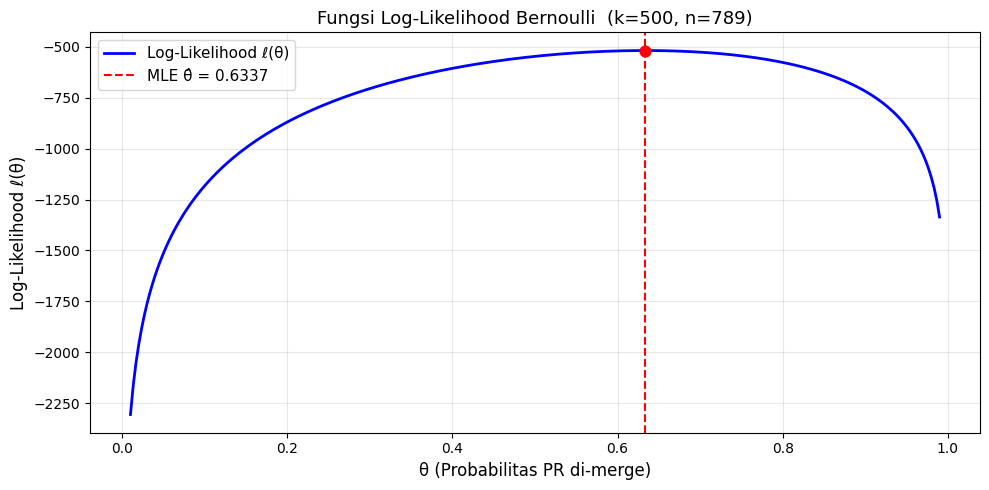

In [30]:

theta_range = np.linspace(0.01, 0.99, 300)
ll_values = [log_likelihood_bernoulli(t, k, n) for t in theta_range]

plt.figure(figsize=(10, 5))
plt.plot(theta_range, ll_values, 'b-', linewidth=2, label='Log-Likelihood ℓ(θ)')
plt.axvline(x=theta_hat, color='red', linestyle='--', linewidth=1.5,
            label=f'MLE θ̂ = {theta_hat:.4f}')
plt.scatter([theta_hat], [log_likelihood_bernoulli(theta_hat, k, n)],
            color='red', zorder=5, s=60)
plt.xlabel('θ (Probabilitas PR di-merge)', fontsize=12)
plt.ylabel('Log-Likelihood ℓ(θ)', fontsize=12)
plt.title(f'Fungsi Log-Likelihood Bernoulli  (k={k}, n={n})', fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 5.2 Distribusi Prior dan Posterior Beta

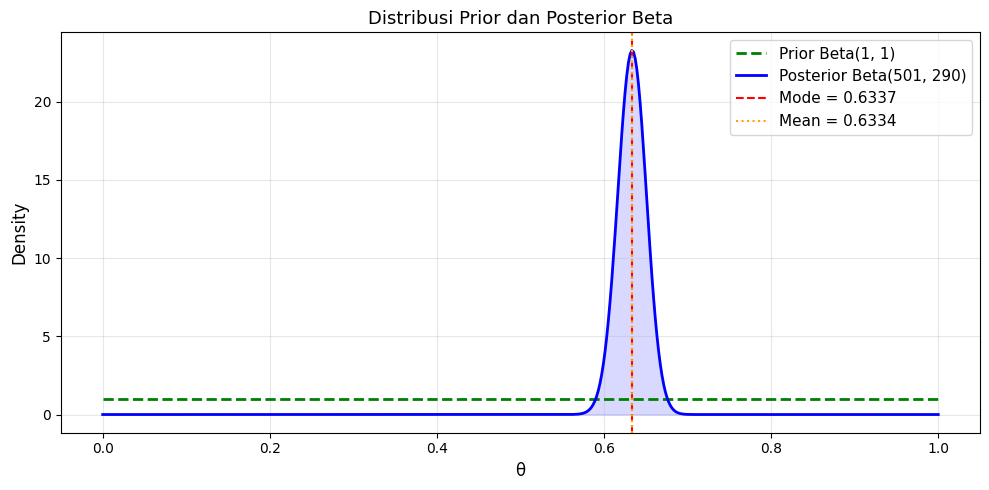

In [31]:
x = np.linspace(0, 1, 500)
alpha = posterior['alpha']
beta_param = posterior['beta']

prior_pdf = beta_dist.pdf(x, 1, 1)
posterior_pdf = beta_dist.pdf(x, alpha, beta_param)

plt.figure(figsize=(10, 5))
plt.plot(x, prior_pdf, 'g--', linewidth=2, label='Prior Beta(1, 1)')
plt.plot(x, posterior_pdf, 'b-', linewidth=2,
         label=f'Posterior Beta({alpha}, {beta_param})')
plt.axvline(x=posterior['mode'], color='red', linestyle='--', linewidth=1.5,
            label=f"Mode = {posterior['mode']:.4f}")
plt.axvline(x=posterior['mean'], color='orange', linestyle=':', linewidth=1.5,
            label=f"Mean = {posterior['mean']:.4f}")
plt.fill_between(x, 0, posterior_pdf, alpha=0.15, color='blue')
plt.xlabel('θ', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.title('Distribusi Prior dan Posterior Beta', fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 5.3 Distribusi Status PR (Merged vs Unmerged)

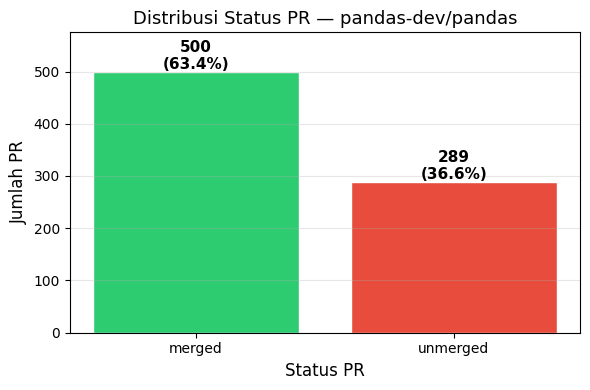

In [32]:
status_counts = df_pr['status'].value_counts()
colors = ['#2ecc71' if s == 'merged' else '#e74c3c' for s in status_counts.index]

plt.figure(figsize=(6, 4))
bars = plt.bar(status_counts.index, status_counts.values, color=colors, edgecolor='white')
for bar, val in zip(bars, status_counts.values):
    pct = val / n * 100
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
             f'{val}\n({pct:.1f}%)', ha='center', fontweight='bold', fontsize=11)
plt.title('Distribusi Status PR — pandas-dev/pandas', fontsize=13)
plt.xlabel('Status PR', fontsize=12)
plt.ylabel('Jumlah PR', fontsize=12)
plt.ylim(0, max(status_counts.values) * 1.15)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretasi Hasil Estimasi Q1

#### 1. Perbandingan Nilai Estimasi
Berdasarkan analisis estimasi, diperoleh hasil dari beberapa metode sebagai berikut:

* **MLE Bernoulli ($\hat{\theta} = k/n$):** $\approx 0.6337$
* **Mode Beta Posterior:** $\approx 0.6337$
* **Mean Beta Posterior:** $\approx 0.6334$

Nilai estimasi dari metode *Maximum Likelihood Estimation* (MLE) Bernoulli dan Mode Beta Posterior menunjukkan hasil yang identik karena penggunaan *uniform prior* tidak memengaruhi titik puncak (modus) distribusi. Sementara itu, nilai *Mean posterior* menunjukkan sedikit perbedaan karena memperhitungkan efek *smoothing* dari *prior*. Hal ini sangat membantu dalam memperhitungkan ketidakpastian, terutama ketika ukuran sampel yang digunakan kecil.

#### 2. Analisis Ketidakpastian
Kurva posterior Beta yang terbentuk memiliki karakteristik yang tajam dan sempit. Hal ini menunjukkan bahwa estimasi kita memiliki **tingkat ketidakpastian yang rendah**. Rendahnya ketidakpastian ini dipengaruhi oleh ukuran sampel data yang cukup besar ($n > 700$). Semakin tajam kurva yang dihasilkan, semakin tinggi tingkat keyakinan kita terhadap nilai $\theta$ yang diestimasi.

#### 3. Interpretasi Kontekstual
Dari hasil di atas, probabilitas sebuah *Pull Request* (PR) di-merge di repository `pandas-dev/pandas` diestimasi sebesar **$\approx 63.4\%$**. 

Secara kontekstual, angka ini menunjukkan bahwa proses *review* pada repository pandas memiliki standar yang **cukup selektif**. Meskipun lebih dari setengah jumlah PR yang masuk berhasil diterima dan di-merge, terdapat sekitar $36.6\%$ PR yang ditolak atau tidak di-merge. Hal ini mengindikasikan bahwa tim *maintainer* tetap menjaga standar kualitas kode secara konsisten sebelum menggabungkannya ke dalam *main branch*.

## Summary

Dari analisis estimasi pada Q1, diperoleh:

| Metode | Nilai θ |
|---|---|
| MLE Bernoulli (θ̂ = k/n) | ≈ 0.6337 |
| Mode Beta Posterior | ≈ 0.6337 |
| Mean Beta Posterior | ≈ 0.6334 |

**Kesimpulan Q1:**  
Probabilitas sebuah PR di-merge di `pandas-dev/pandas` diestimasi sebesar **≈ 63.4%** dengan tingkat ketidakpastian yang rendah (kurva posterior sempit). Nilai ini akan diteruskan ke **Member C (Inference Analyst)** untuk konstruksi confidence interval dan credible interval terhadap parameter θ ini.